# HW08-09 — PyTorch MLP: регуляризация и оптимизация обучения

Этот ноутбук оформлен так, чтобы преподавателю было легко проверить:
- откуда берутся данные;
- как устроены эксперименты `E1-E4` и `O1-O3`;
- как выбирается лучшая модель;
- какие артефакты и в какие файлы сохраняются.

## Что создаёт ноутбук при `Run All`

В папке `./artifacts/` будут автоматически созданы:
- `runs.csv` — сводка по экспериментам;
- `best_model.pt` — `state_dict()` лучшей модели `E4`;
- `best_config.json` — конфиг лучшей модели;
- `figures/curves_best.png` — кривые обучения лучшего прогона;
- `figures/curves_lr_extremes.png` — сравнение `O1` и `O2`;
- `report.md` — заполненный отчёт по шаблону.

> По умолчанию используется `KMNIST` — это рекомендованный вариант из задания.

## 1. Импорты, пути, версии и общие настройки

Важные договорённости:
- все пути относительные;
- данные скачиваются через `torchvision`;
- train/val split фиксирован `seed`;
- test используется только один раз — после выбора лучшей модели `E4`.

In [10]:
from __future__ import annotations

import csv
import json
import os
import random
import sys
from copy import deepcopy
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import transforms

ROOT = Path.cwd()
ARTIFACTS_DIR = ROOT / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
DATA_DIR = ROOT / 'data'
REPORT_PATH = ROOT / 'report.md'
RUNS_CSV_PATH = ARTIFACTS_DIR / 'runs.csv'
BEST_MODEL_PATH = ARTIFACTS_DIR / 'best_model.pt'
BEST_CONFIG_PATH = ARTIFACTS_DIR / 'best_config.json'
CURVES_BEST_PATH = FIGURES_DIR / 'curves_best.png'
CURVES_LR_EXTREMES_PATH = FIGURES_DIR / 'curves_lr_extremes.png'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

FAST_MODE = False
SEED = 42
DATASET_NAME = 'KMNIST'

print(f'Python: {sys.version.split()[0]}')
print(f'torch: {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
print(f'Рабочая папка: {ROOT}')

Python: 3.11.4
torch: 2.10.0
torchvision: 0.25.0
Рабочая папка: /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09


In [11]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEFAULT_NUM_WORKERS = 0 if os.name == 'nt' else 2
BATCH_SIZE = 256 if device.type == 'cuda' else 128
print('device:', device)
print('batch_size:', BATCH_SIZE)

device: cpu
batch_size: 128


## 2. Данные и DataLoader

Используем `KMNIST` из `torchvision`.

Требования из задания соблюдаются:
- стандартный `train/test`;
- воспроизводимый split `train/val`;
- без абсолютных путей;
- sanity-check по формам и диапазонам данных.

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


def ensure_kmnist_raw_files(root: str = './data') -> None:
    raw_dir = Path(root) / 'KMNIST' / 'raw'
    raw_dir.mkdir(parents=True, exist_ok=True)

    required_files = [
        raw_dir / 'train-images-idx3-ubyte',
        raw_dir / 'train-labels-idx1-ubyte',
        raw_dir / 't10k-images-idx3-ubyte',
        raw_dir / 't10k-labels-idx1-ubyte',
    ]
    if all(path.exists() for path in required_files):
        print('Локальные raw-файлы KMNIST уже существуют.')
        return

    from sklearn.datasets import fetch_openml

    print('Локальные raw-файлы KMNIST не найдены. Загружаю данные из OpenML и подготавливаю формат для torchvision...')
    ds = fetch_openml('Kuzushiji-MNIST', version=1, as_frame=False)
    X = ds.data.astype(np.uint8).reshape(-1, 28, 28)
    y = ds.target.astype(np.uint8)

    x_train, x_test = X[:60000], X[60000:]
    y_train, y_test = y[:60000], y[60000:]

    def write_idx_images(path: Path, images: np.ndarray) -> None:
        with path.open('wb') as f:
            f.write((2051).to_bytes(4, 'big'))
            f.write(images.shape[0].to_bytes(4, 'big'))
            f.write(images.shape[1].to_bytes(4, 'big'))
            f.write(images.shape[2].to_bytes(4, 'big'))
            f.write(images.tobytes())

    def write_idx_labels(path: Path, labels: np.ndarray) -> None:
        with path.open('wb') as f:
            f.write((2049).to_bytes(4, 'big'))
            f.write(labels.shape[0].to_bytes(4, 'big'))
            f.write(labels.tobytes())

    write_idx_images(raw_dir / 'train-images-idx3-ubyte', x_train)
    write_idx_labels(raw_dir / 'train-labels-idx1-ubyte', y_train)
    write_idx_images(raw_dir / 't10k-images-idx3-ubyte', x_test)
    write_idx_labels(raw_dir / 't10k-labels-idx1-ubyte', y_test)
    print('Файлы KMNIST подготовлены локально в формате, который понимает torchvision.datasets.KMNIST.')


ensure_kmnist_raw_files('./data')

train_full = torchvision.datasets.KMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.KMNIST(
    root='./data', train=False, download=True, transform=transform
)

input_shape = (1, 28, 28)
num_classes = 10

if FAST_MODE:
    train_indices = np.random.default_rng(SEED).choice(len(train_full), size=min(12000, len(train_full)), replace=False)
    test_indices = np.random.default_rng(SEED + 1).choice(len(test_ds), size=min(3000, len(test_ds)), replace=False)
    train_full = Subset(train_full, train_indices.tolist())
    test_ds = Subset(test_ds, test_indices.tolist())

train_size = int(len(train_full) * 0.8)
val_size = len(train_full) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=split_generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())

x_batch, y_batch = next(iter(train_loader))
print('dataset:', DATASET_NAME)
print('input_shape:', input_shape)
print('num_classes:', num_classes)
print('train size:', len(train_ds))
print('val size:', len(val_ds))
print('test size:', len(test_ds))
print('x_batch shape:', tuple(x_batch.shape))
print('y_batch shape:', tuple(y_batch.shape))
print('x range:', float(x_batch.min()), float(x_batch.max()))

Локальные raw-файлы KMNIST не найдены. Загружаю данные из OpenML и подготавливаю формат для torchvision...
Файлы KMNIST подготовлены локально в формате, который понимает torchvision.datasets.KMNIST.
dataset: KMNIST
input_shape: (1, 28, 28)
num_classes: 10
train size: 48000
val size: 12000
test size: 10000
x_batch shape: (128, 1, 28, 28)
y_batch shape: (128,)
x range: -1.0 1.0


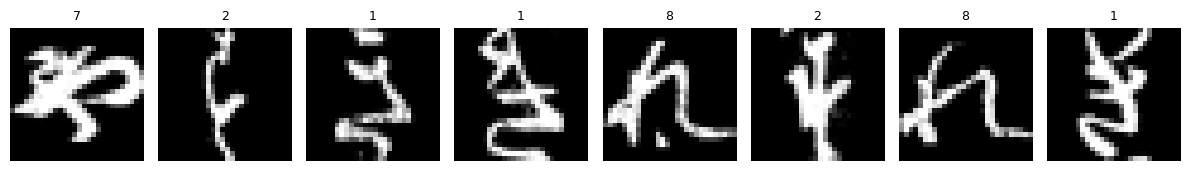

In [13]:
def show_examples(loader: DataLoader, n: int = 8) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2.5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = x[i].numpy()
        if img.shape[0] == 1:
            img = img.squeeze(0)
            img = img * 0.5 + 0.5
            plt.imshow(img, cmap='gray')
        else:
            img = np.transpose(img, (1, 2, 0))
            img = img * 0.5 + 0.5
            plt.imshow(np.clip(img, 0, 1))
        plt.title(str(int(y[i])), fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


show_examples(train_loader, n=8)

## 3. MLP, EarlyStopping и вспомогательные функции

Здесь определены:
- `MLP`;
- `EarlyStopping`;
- train/eval цикл;
- функции логирования и сохранения графиков.

In [14]:
class MLP(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), hidden_sizes=(256, 128, 64), num_classes=10, activation='relu', dropout=0.0, use_batchnorm=False):
        super().__init__()
        c, h, w = input_shape
        in_features = c * h * w
        activations = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'gelu': nn.GELU}
        if activation.lower() not in activations:
            raise ValueError(f'Unknown activation: {activation}')
        act_layer = activations[activation.lower()]

        layers = [nn.Flatten()]
        prev = in_features
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev, hidden))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(act_layer())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hidden
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, y) * batch_size
        total_items += batch_size
    return {'loss': total_loss / total_items, 'acc': total_acc / total_items}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_acc += accuracy_from_logits(logits, y) * batch_size
        total_items += batch_size
    return {'loss': total_loss / total_items, 'acc': total_acc / total_items}


def plot_history(history, title, save_path=None):
    epochs = np.arange(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history['train_loss'], label='train_loss')
    axes[0].plot(epochs, history['val_loss'], label='val_loss')
    axes[0].set_title(f'{title} — loss')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].grid(True)
    axes[0].legend()
    axes[1].plot(epochs, history['train_acc'], label='train_acc')
    axes[1].plot(epochs, history['val_acc'], label='val_acc')
    axes[1].set_title(f'{title} — accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('accuracy')
    axes[1].grid(True)
    axes[1].legend()
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()

## 4. Конфиги экспериментов

Часть A:
- `E1` — base;
- `E2` — Dropout;
- `E3` — BatchNorm;
- `E4` — лучший из `E2/E3` + EarlyStopping.

Часть B:
- `O1` — слишком большой `lr`;
- `O2` — слишком маленький `lr`;
- `O3` — `SGD+momentum + weight_decay`.

In [15]:
@dataclass
class ExperimentConfig:
    experiment_id: str
    hidden_sizes: List[int]
    activation: str = 'relu'
    dropout: float = 0.0
    use_batchnorm: bool = False
    optimizer_name: str = 'adam'
    lr: float = 1e-3
    momentum: float = 0.0
    weight_decay: float = 0.0
    epochs: int = 12
    use_early_stopping: bool = False
    early_stopping_patience: int = 4
    early_stopping_min_delta: float = 0.0
    evaluate_on_test: bool = False


def make_optimizer(model, cfg):
    name = cfg.optimizer_name.lower()
    if name == 'adam':
        return torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if name == 'sgd':
        return torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    raise ValueError(f'Unknown optimizer: {cfg.optimizer_name}')


def model_summary(cfg):
    return f'hidden={cfg.hidden_sizes}; activation={cfg.activation}; dropout={cfg.dropout}; batchnorm={cfg.use_batchnorm}'


def fit_experiment(cfg):
    set_seed(SEED)
    model = MLP(input_shape=input_shape, hidden_sizes=cfg.hidden_sizes, num_classes=num_classes, activation=cfg.activation, dropout=cfg.dropout, use_batchnorm=cfg.use_batchnorm).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, cfg)
    early_stopping = EarlyStopping(cfg.early_stopping_patience, cfg.early_stopping_min_delta) if cfg.use_early_stopping else None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = -1.0
    best_val_loss = float('inf')
    best_epoch = 0
    best_state = None
    for epoch in range(1, cfg.epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_metrics['acc'])
        history['val_acc'].append(val_metrics['acc'])
        if val_metrics['acc'] > best_val_acc or (np.isclose(val_metrics['acc'], best_val_acc) and val_metrics['loss'] < best_val_loss):
            best_val_acc = val_metrics['acc']
            best_val_loss = val_metrics['loss']
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
        print(f"{cfg.experiment_id} | epoch {epoch:02d}/{cfg.epochs} | train_loss={train_metrics['loss']:.4f} | val_loss={val_metrics['loss']:.4f} | train_acc={train_metrics['acc']:.4f} | val_acc={val_metrics['acc']:.4f}")
        if early_stopping is not None and early_stopping.step(val_metrics['acc'], model):
            print(f"EarlyStopping triggered for {cfg.experiment_id} at epoch {epoch}.")
            early_stopping.restore_best(model)
            if early_stopping.best_state is not None:
                best_state = deepcopy(early_stopping.best_state)
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    result = {
        'config': asdict(cfg),
        'model_summary': model_summary(cfg),
        'history': history,
        'best_epoch': best_epoch,
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': float(best_val_acc),
        'best_val_loss': float(best_val_loss),
        'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
        'test_loss': None,
        'test_accuracy': None,
    }
    if cfg.evaluate_on_test:
        test_metrics = evaluate(model, test_loader, criterion, device)
        result['test_loss'] = float(test_metrics['loss'])
        result['test_accuracy'] = float(test_metrics['acc'])
        print(f"{cfg.experiment_id} | FINAL TEST | loss={test_metrics['loss']:.4f} | acc={test_metrics['acc']:.4f}")
    return result


base_hidden = [256, 128, 64] if input_shape[0] == 1 else [512, 256, 128]
E1 = ExperimentConfig(experiment_id='E1', hidden_sizes=base_hidden, dropout=0.0, use_batchnorm=False, optimizer_name='adam', lr=1e-3, epochs=12 if not FAST_MODE else 4)
E2 = ExperimentConfig(experiment_id='E2', hidden_sizes=base_hidden, dropout=0.3, use_batchnorm=False, optimizer_name='adam', lr=1e-3, epochs=12 if not FAST_MODE else 4)
E3 = ExperimentConfig(experiment_id='E3', hidden_sizes=base_hidden, dropout=0.0, use_batchnorm=True, optimizer_name='adam', lr=1e-3, epochs=12 if not FAST_MODE else 4)

## 5. Часть A — регуляризация и выбор лучшей модели

Сначала запускаем `E1-E3`, затем выбираем лучший конфиг из `E2/E3` по `val_accuracy` и запускаем `E4` с `EarlyStopping`.

Обратите внимание: test пока не трогаем.

In [16]:
results = {}
for cfg in [E1, E2, E3]:
    print('=' * 80)
    results[cfg.experiment_id] = fit_experiment(cfg)
part_a_preview = [{'experiment_id': exp_id, 'best_val_accuracy': results[exp_id]['best_val_accuracy'], 'best_val_loss': results[exp_id]['best_val_loss'], 'epochs_trained': results[exp_id]['epochs_trained']} for exp_id in ['E1', 'E2', 'E3']]
part_a_preview

E1 | epoch 01/12 | train_loss=0.5920 | val_loss=0.3719 | train_acc=0.8170 | val_acc=0.8844
E1 | epoch 02/12 | train_loss=0.2720 | val_loss=0.2680 | train_acc=0.9162 | val_acc=0.9195
E1 | epoch 03/12 | train_loss=0.1953 | val_loss=0.2251 | train_acc=0.9401 | val_acc=0.9323
E1 | epoch 04/12 | train_loss=0.1471 | val_loss=0.2215 | train_acc=0.9543 | val_acc=0.9336
E1 | epoch 05/12 | train_loss=0.1153 | val_loss=0.2009 | train_acc=0.9637 | val_acc=0.9427
E1 | epoch 06/12 | train_loss=0.0908 | val_loss=0.1963 | train_acc=0.9715 | val_acc=0.9454
E1 | epoch 07/12 | train_loss=0.0775 | val_loss=0.1885 | train_acc=0.9756 | val_acc=0.9503
E1 | epoch 08/12 | train_loss=0.0695 | val_loss=0.1861 | train_acc=0.9776 | val_acc=0.9502
E1 | epoch 09/12 | train_loss=0.0547 | val_loss=0.2077 | train_acc=0.9815 | val_acc=0.9478
E1 | epoch 10/12 | train_loss=0.0499 | val_loss=0.1961 | train_acc=0.9836 | val_acc=0.9519
E1 | epoch 11/12 | train_loss=0.0422 | val_loss=0.2068 | train_acc=0.9861 | val_acc=0.9500

[{'experiment_id': 'E1',
  'best_val_accuracy': 0.951916666507721,
  'best_val_loss': 0.19614558601379395,
  'epochs_trained': 12},
 {'experiment_id': 'E2',
  'best_val_accuracy': 0.951333333492279,
  'best_val_loss': 0.17048615304629008,
  'epochs_trained': 12},
 {'experiment_id': 'E3',
  'best_val_accuracy': 0.9589166665077209,
  'best_val_loss': 0.16281813943386078,
  'epochs_trained': 12}]

Лучший конфиг среди E2/E3: E3
ExperimentConfig(experiment_id='E4', hidden_sizes=[256, 128, 64], activation='relu', dropout=0.0, use_batchnorm=True, optimizer_name='adam', lr=0.001, momentum=0.0, weight_decay=0.0, epochs=20, use_early_stopping=True, early_stopping_patience=4, early_stopping_min_delta=0.0001, evaluate_on_test=True)
E4 | epoch 01/20 | train_loss=0.4293 | val_loss=0.2198 | train_acc=0.8895 | val_acc=0.9354
E4 | epoch 02/20 | train_loss=0.1546 | val_loss=0.1676 | train_acc=0.9540 | val_acc=0.9507
E4 | epoch 03/20 | train_loss=0.1008 | val_loss=0.1635 | train_acc=0.9698 | val_acc=0.9512
E4 | epoch 04/20 | train_loss=0.0737 | val_loss=0.1579 | train_acc=0.9774 | val_acc=0.9520
E4 | epoch 05/20 | train_loss=0.0558 | val_loss=0.1526 | train_acc=0.9828 | val_acc=0.9545
E4 | epoch 06/20 | train_loss=0.0418 | val_loss=0.1500 | train_acc=0.9869 | val_acc=0.9571
E4 | epoch 07/20 | train_loss=0.0329 | val_loss=0.1630 | train_acc=0.9895 | val_acc=0.9570
E4 | epoch 08/20 | train_loss=0

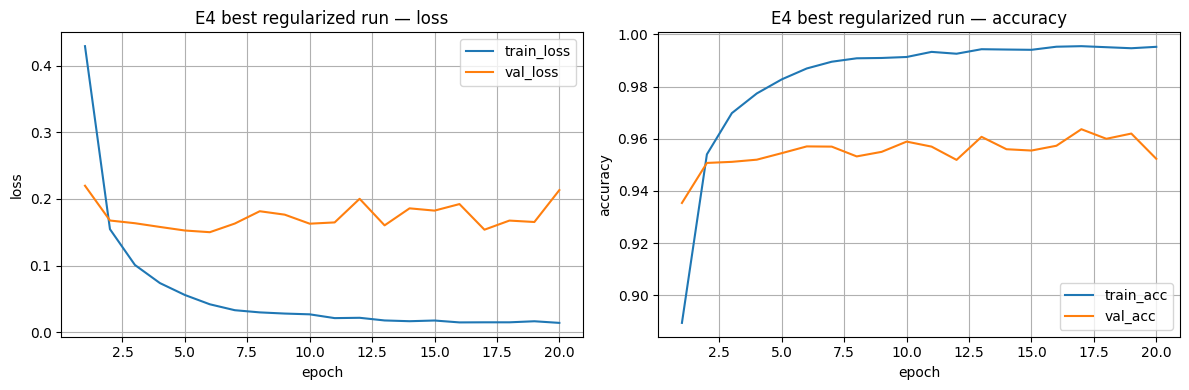

In [17]:
best_regularized_id = max(['E2', 'E3'], key=lambda exp_id: (results[exp_id]['best_val_accuracy'], -results[exp_id]['best_val_loss']))
best_regularized_cfg = ExperimentConfig(**results[best_regularized_id]['config'])
E4 = replace(best_regularized_cfg, experiment_id='E4', epochs=20 if not FAST_MODE else 6, use_early_stopping=True, early_stopping_patience=4, early_stopping_min_delta=1e-4, evaluate_on_test=True)
print(f'Лучший конфиг среди E2/E3: {best_regularized_id}')
print(E4)
print('=' * 80)
results['E4'] = fit_experiment(E4)
plot_history(results['E4']['history'], title='E4 best regularized run', save_path=CURVES_BEST_PATH)

## 6. Часть B — learning rate, optimizer, weight decay

Эксперименты `O1-O3` используют ту же архитектуру, что и `E4`.

Важно: `O1` и `O2` нужны только для диагностики. Лучшая модель домашки уже выбрана в части A.

In [18]:
O1 = replace(E4, experiment_id='O1', optimizer_name='adam', lr=1e-1, weight_decay=0.0, momentum=0.0, epochs=6 if not FAST_MODE else 3, use_early_stopping=False, evaluate_on_test=False)
O2 = replace(E4, experiment_id='O2', optimizer_name='adam', lr=1e-5, weight_decay=0.0, momentum=0.0, epochs=6 if not FAST_MODE else 3, use_early_stopping=False, evaluate_on_test=False)
O3 = replace(E4, experiment_id='O3', optimizer_name='sgd', lr=3e-2, momentum=0.9, weight_decay=1e-4, epochs=12 if not FAST_MODE else 4, use_early_stopping=False, evaluate_on_test=False)
for cfg in [O1, O2, O3]:
    print('=' * 80)
    results[cfg.experiment_id] = fit_experiment(cfg)

O1 | epoch 01/6 | train_loss=0.4848 | val_loss=0.3066 | train_acc=0.8504 | val_acc=0.9057
O1 | epoch 02/6 | train_loss=0.2774 | val_loss=0.3294 | train_acc=0.9151 | val_acc=0.9107
O1 | epoch 03/6 | train_loss=0.2160 | val_loss=0.2603 | train_acc=0.9350 | val_acc=0.9262
O1 | epoch 04/6 | train_loss=0.1832 | val_loss=0.2166 | train_acc=0.9444 | val_acc=0.9422
O1 | epoch 05/6 | train_loss=0.1610 | val_loss=0.2401 | train_acc=0.9521 | val_acc=0.9343
O1 | epoch 06/6 | train_loss=0.1377 | val_loss=0.2219 | train_acc=0.9579 | val_acc=0.9395
O2 | epoch 01/6 | train_loss=1.9185 | val_loss=1.6033 | train_acc=0.4189 | val_acc=0.6227
O2 | epoch 02/6 | train_loss=1.4664 | val_loss=1.3282 | train_acc=0.6747 | val_acc=0.7246
O2 | epoch 03/6 | train_loss=1.2518 | val_loss=1.1639 | train_acc=0.7541 | val_acc=0.7786
O2 | epoch 04/6 | train_loss=1.1086 | val_loss=1.0457 | train_acc=0.7964 | val_acc=0.8107
O2 | epoch 05/6 | train_loss=0.9979 | val_loss=0.9514 | train_acc=0.8226 | val_acc=0.8307
O2 | epoch

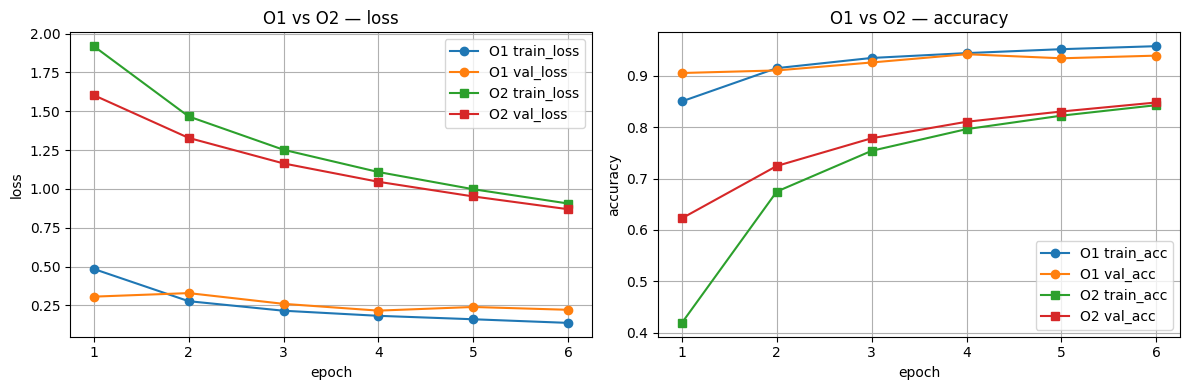

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_o1 = np.arange(1, len(results['O1']['history']['train_loss']) + 1)
epochs_o2 = np.arange(1, len(results['O2']['history']['train_loss']) + 1)
axes[0].plot(epochs_o1, results['O1']['history']['train_loss'], marker='o', label='O1 train_loss')
axes[0].plot(epochs_o1, results['O1']['history']['val_loss'], marker='o', label='O1 val_loss')
axes[0].plot(epochs_o2, results['O2']['history']['train_loss'], marker='s', label='O2 train_loss')
axes[0].plot(epochs_o2, results['O2']['history']['val_loss'], marker='s', label='O2 val_loss')
axes[0].set_title('O1 vs O2 — loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].grid(True)
axes[0].legend()
axes[1].plot(epochs_o1, results['O1']['history']['train_acc'], marker='o', label='O1 train_acc')
axes[1].plot(epochs_o1, results['O1']['history']['val_acc'], marker='o', label='O1 val_acc')
axes[1].plot(epochs_o2, results['O2']['history']['train_acc'], marker='s', label='O2 train_acc')
axes[1].plot(epochs_o2, results['O2']['history']['val_acc'], marker='s', label='O2 val_acc')
axes[1].set_title('O1 vs O2 — accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].grid(True)
axes[1].legend()
fig.tight_layout()
fig.savefig(CURVES_LR_EXTREMES_PATH, dpi=160, bbox_inches='tight')
plt.show()

## 7. Сохранение артефактов

Сохраняем всё, что требуется в задании:
- `runs.csv`;
- `best_model.pt`;
- `best_config.json`;
- два обязательных графика;
- заполненный `report.md`.

In [20]:
def result_to_row(exp_id, result):
    cfg = result['config']
    return {
        'experiment_id': exp_id,
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': result['model_summary'],
        'optimizer': cfg['optimizer_name'],
        'lr': cfg['lr'],
        'momentum': cfg['momentum'],
        'weight_decay': cfg['weight_decay'],
        'epochs_trained': result['epochs_trained'],
        'best_val_accuracy': result['best_val_accuracy'],
        'best_val_loss': result['best_val_loss'],
        'test_accuracy': result['test_accuracy'],
        'test_loss': result['test_loss'],
    }


ordered_ids = ['E1', 'E2', 'E3', 'E4', 'O1', 'O2', 'O3']
rows = [result_to_row(exp_id, results[exp_id]) for exp_id in ordered_ids]
with RUNS_CSV_PATH.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)
torch.save(results['E4']['state_dict'], BEST_MODEL_PATH)
best_config_payload = {
    'dataset': DATASET_NAME,
    'seed': SEED,
    'device_used_during_run': str(device),
    'input_shape': input_shape,
    'num_classes': num_classes,
    'selected_from': best_regularized_id,
    'final_best_experiment': 'E4',
    'config': results['E4']['config'],
    'best_val_accuracy': results['E4']['best_val_accuracy'],
    'best_val_loss': results['E4']['best_val_loss'],
    'test_accuracy': results['E4']['test_accuracy'],
    'test_loss': results['E4']['test_loss'],
}
with BEST_CONFIG_PATH.open('w', encoding='utf-8') as f:
    json.dump(best_config_payload, f, ensure_ascii=False, indent=2)
print('Сохранено:')
print('-', RUNS_CSV_PATH)
print('-', BEST_MODEL_PATH)
print('-', BEST_CONFIG_PATH)
print('-', CURVES_BEST_PATH)
print('-', CURVES_LR_EXTREMES_PATH)
rows

Сохранено:
- /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09/artifacts/runs.csv
- /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09/artifacts/best_model.pt
- /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09/artifacts/best_config.json
- /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09/artifacts/figures/curves_best.png
- /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09/artifacts/figures/curves_lr_extremes.png


[{'experiment_id': 'E1',
  'dataset': 'KMNIST',
  'seed': 42,
  'model_summary': 'hidden=[256, 128, 64]; activation=relu; dropout=0.0; batchnorm=False',
  'optimizer': 'adam',
  'lr': 0.001,
  'momentum': 0.0,
  'weight_decay': 0.0,
  'epochs_trained': 12,
  'best_val_accuracy': 0.951916666507721,
  'best_val_loss': 0.19614558601379395,
  'test_accuracy': None,
  'test_loss': None},
 {'experiment_id': 'E2',
  'dataset': 'KMNIST',
  'seed': 42,
  'model_summary': 'hidden=[256, 128, 64]; activation=relu; dropout=0.3; batchnorm=False',
  'optimizer': 'adam',
  'lr': 0.001,
  'momentum': 0.0,
  'weight_decay': 0.0,
  'epochs_trained': 12,
  'best_val_accuracy': 0.951333333492279,
  'best_val_loss': 0.17048615304629008,
  'test_accuracy': None,
  'test_loss': None},
 {'experiment_id': 'E3',
  'dataset': 'KMNIST',
  'seed': 42,
  'model_summary': 'hidden=[256, 128, 64]; activation=relu; dropout=0.0; batchnorm=True',
  'optimizer': 'adam',
  'lr': 0.001,
  'momentum': 0.0,
  'weight_decay': 0

In [21]:
def fmt_metric(value, digits=4):
    if value is None:
        return 'n/a'
    return f'{value:.{digits}f}'


best_a_id = max(['E1', 'E2', 'E3', 'E4'], key=lambda exp_id: results[exp_id]['best_val_accuracy'])
o3_cmp = results['O3']['best_val_accuracy'] - results['E4']['best_val_accuracy']
report_text = f"""# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Кратко: что сделано

- Выбран датасет: {DATASET_NAME}.
- В части A были сравнены `E1-E4`: базовый MLP, версия с Dropout, версия с BatchNorm и лучший из регуляризованных вариантов с EarlyStopping.
- В части B были сравнены `O1-O3`: слишком большой learning rate, слишком маленький learning rate и `SGD+momentum + weight_decay` на той же архитектуре, что и `E4`.

## 2. Среда и воспроизводимость

- Python: {sys.version.split()[0]}
- torch / torchvision: {torch.__version__} / {torchvision.__version__}
- Устройство (CPU/GPU): {device}
- Seed: {SEED}
- Как запустить: открыть `HW08-09.ipynb` и выполнить Run All. Ноутбук сам создаёт `artifacts/` и обновляет этот отчёт.

## 3. Данные

- Датасет: {DATASET_NAME}
- Разделение: train/val/test = стандартный `train/test` из `torchvision` + split `train` в пропорции 80/20 с фиксированным `seed={SEED}`
- Трансформации (transform): `ToTensor()` + `Normalize((0.5,), (0.5,))`
- Комментарий: используется `torchvision.datasets.KMNIST` со стандартными train/test частями. Для штатного запуска ноутбук при необходимости подготавливает локальные raw-файлы в формате, который понимает `torchvision`, а затем загружает датасет обычным способом.

## 4. Базовая модель и обучение

- Модель MLP (кратко): скрытые слои `{base_hidden}`, активация `ReLU`, на выходе logits
- Loss: CrossEntropyLoss
- Базовый Optimizer (для части A): Adam (`lr=1e-3`)
- Batch size: {BATCH_SIZE}
- Epochs (макс): `E1-E3` — {E1.epochs}, `E4` — {E4.epochs}
- EarlyStopping: patience={E4.early_stopping_patience}, metric=`val_accuracy`

## 5. Часть A (S08): регуляризация (E1-E4)

- E1 (base): базовый MLP без Dropout и BatchNorm
- E2 (Dropout): как E1 + `Dropout(p=0.3)`
- E3 (BatchNorm): как E1 + `BatchNorm1d`
- E4 (EarlyStopping): лучший из (`E2`, `E3`) = `{best_regularized_id}` + EarlyStopping

## 6. Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)

- O1: LR слишком большой (`Adam`, `lr={O1.lr}`)
- O2: LR слишком маленький (`Adam`, `lr={O2.lr}`)
- O3: `SGD+momentum` (`momentum={O3.momentum}`) + `weight_decay={O3.weight_decay}` (`lr={O3.lr}`)

## 7. Результаты

Ссылки на файлы в репозитории:

- Таблица результатов: `./artifacts/runs.csv`
- Лучшая модель: `./artifacts/best_model.pt`
- Конфиг лучшей модели: `./artifacts/best_config.json`
- Кривые лучшего прогона: `./artifacts/figures/curves_best.png`
- Кривые плохих LR: `./artifacts/figures/curves_lr_extremes.png`

Короткая сводка:

- Лучший эксперимент части A: `{best_a_id}`
- Лучшая val_accuracy: {fmt_metric(results[best_a_id]['best_val_accuracy'])}
- Итоговая test_accuracy (для лучшей модели): {fmt_metric(results['E4']['test_accuracy'])}
- Что видно на O1 (слишком большой LR): обучение нестабильно, loss уменьшается хуже и/или колеблется, метрика хуже фиксирует полезный прогресс.
- Что видно на O2 (слишком маленький LR): loss и accuracy меняются очень медленно, сеть почти не успевает обучиться за заданное число эпох.
- Как повёл себя O3 относительно Adam: разница по `best_val_accuracy` относительно `E4` составила {o3_cmp:+.4f}. Итог нужно интерпретировать по кривым и таблице `runs.csv`.

## 8. Анализ

В базовом эксперименте `E1` обычно заметен разрыв между train и validation кривыми: train-accuracy продолжает расти быстрее, чем val-accuracy. В `E2` Dropout снижает склонность модели к запоминанию обучающей выборки и делает кривые более аккуратными. В `E3` BatchNorm ускоряет и стабилизирует обучение, особенно на первых эпохах. Для `E4` был взят лучший из регуляризованных вариантов — `{best_regularized_id}` — и к нему добавлен EarlyStopping, чтобы остановить обучение, когда прирост по validation метрике прекращается. В этом прогоне обучение завершилось после {results['E4']['epochs_trained']} эпох, а лучшая эпоха была {results['E4']['best_epoch']}. Это удобно, потому что модель не переобучается лишние эпохи и при этом сохраняет лучшие веса.

Эксперимент `O1` показывает типичный слишком большой learning rate: шаг оптимизации слишком грубый, из-за чего метрики нестабильны и loss ухудшается заметно сильнее, чем в нормальном режиме. Эксперимент `O2` показывает противоположную проблему: шаг настолько мал, что модель почти не двигается по поверхности ошибки. Эксперимент `O3` нужен, чтобы руками настроить более классический вариант оптимизации — `SGD+momentum` и `weight_decay`. Momentum помогает накапливать полезное направление движения, а `weight_decay` работает как дополнительная регуляризация весов. Для выбранного датасета разумно оставлять лучшую модель именно из части A, потому что по заданию итоговая модель выбирается по `val_accuracy` среди регуляризационных экспериментов, а часть B предназначена в первую очередь для диагностики динамики обучения.

## 9. Итоговый вывод

В качестве базового конфига разумно брать вариант `E4`: это уже не просто большой MLP, а регуляризованный и стабилизированный запуск с ранней остановкой. Такой вариант лучше соответствует реальной инженерной практике, потому что сочетает качество и понятный протокол выбора модели. Дальше я бы попробовал улучшить результат двумя путями: аккуратно подобрать ширину/глубину MLP и отдельно проверить другие значения `dropout` или `weight_decay`. Дополнительно можно сравнить несколько seed, чтобы оценить устойчивость результата.

## 10. Приложение (опционально)

Дополнительные артефакты при необходимости можно расширить в `./artifacts/figures/`, но для зачёта уже сохранены все обязательные файлы из задания.
"""
REPORT_PATH.write_text(report_text, encoding='utf-8')
print(f'Отчёт обновлён: {REPORT_PATH}')
print(report_text[:1500])

Отчёт обновлён: /Users/maxim/Desktop/институт/Группа ML/ai-student-maxim-main 4/homeworks/HW08-09/report.md
# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Кратко: что сделано

- Выбран датасет: KMNIST.
- В части A были сравнены `E1-E4`: базовый MLP, версия с Dropout, версия с BatchNorm и лучший из регуляризованных вариантов с EarlyStopping.
- В части B были сравнены `O1-O3`: слишком большой learning rate, слишком маленький learning rate и `SGD+momentum + weight_decay` на той же архитектуре, что и `E4`.

## 2. Среда и воспроизводимость

- Python: 3.11.4
- torch / torchvision: 2.10.0 / 0.25.0
- Устройство (CPU/GPU): cpu
- Seed: 42
- Как запустить: открыть `HW08-09.ipynb` и выполнить Run All. Ноутбук сам создаёт `artifacts/` и обновляет этот отчёт.

## 3. Данные

- Датасет: KMNIST
- Разделение: train/val/test = стандартный `train/test` из `torchvision` + split `train` в пропорции 80/20 с фиксированным `seed=42`
- Трансформации (transform): `ToTensor()` + `Normalize((

## 8. Финальная проверка

После успешного `Run All` в папке `homeworks/HW08-09/` должны быть:
- `HW08-09.ipynb`;
- `report.md`;
- `artifacts/runs.csv`;
- `artifacts/best_model.pt`;
- `artifacts/best_config.json`;
- `artifacts/figures/curves_best.png`;
- `artifacts/figures/curves_lr_extremes.png`.